Rezolvare de 96/100

Este simpla si scurta, fiind bazata doar pe procesare de imagini cu OpenCV, fara niciun model utilizat.

In [118]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import pandas as pd
import numpy as np
import cv2

import os

In [119]:
seed = 42
root_path = "/home/stefan/ioai-prep/kits/roai-2025/hotspot"

# Data preparation

In [120]:
def image_to_rle(img_arr: np.array) -> list[int]:
    side, side = img_arr.shape[0], img_arr.shape[1]
    img_arr = img_arr.reshape(side*side, order='F')
    
    start = 0
    length = 0
    res = []
    for i in range(side * side):
        if img_arr[i] == 255:
            if length == 0:
                start = i + 1
            length = length + 1
        else:
            if length > 0:
                res.append(start)
                res.append(length)
            length = 0
    if length > 0:
        res.append(start)
        res.append(length)
        
    return res

In [121]:
def get_subtask_images(subtask_id: int) -> list[np.array]:
    path = f"{root_path}/Satellite_Images-{subtask_id}"
    images = os.listdir(path)
    
    arr = []
    for image_path in images:
        img = np.array(Image.open(f"{path}/{image_path}")) # .shape = (256, 256, 3)
        arr.append({"img": img, "filename": image_path})
    
    return arr

# Image processing

In [122]:
subtask4_images = get_subtask_images(4)
subtask2_images = get_subtask_images(2)

In [134]:
def get_mask(img: np.ndarray, subtask_id: int = 3) -> np.ndarray:
    if subtask_id == 0:
        # Logic for subtasks 0 and 1: Keep only maximum intensity pixels
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        max_val = np.max(gray)
        mask = (gray == max_val).astype(np.uint8) * 255
        return mask

    if subtask_id == 1:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = (gray > 0).astype(np.uint8) * 255
        return mask

    # Logic for subtasks 2 and 3: K-means segmentation
    blurred = cv2.medianBlur(img, 7)
    data = blurred.reshape((-1, 3)).astype(np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    flags = cv2.KMEANS_RANDOM_CENTERS

    _, labels, centers = cv2.kmeans(data, 2, None, criteria, 10, flags)

    # Identify background (lower average intensity)
    background_cluster = np.argmin(np.sum(centers, axis=1))

    mask = (labels.flatten() != background_cluster).astype(np.uint8) * 255
    return mask.reshape(img.shape[0], img.shape[1])

<Figure size 640x480 with 0 Axes>

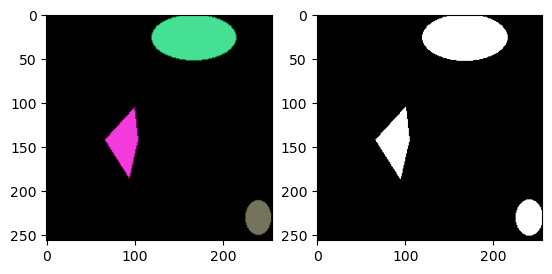

In [135]:
plt.figure()
f, axarr = plt.subplots(1, 2) 

img = subtask2_images[11]["img"]
masked = get_mask(img, 1)

axarr[0].imshow(img)
axarr[1].imshow(masked, cmap='gray')

# Submission

In [136]:
subtasks = [{"masked": [], "id": []} for _ in range(4)]

In [137]:
for subtask_id in range(4):
    subtask_images = get_subtask_images(subtask_id+1)

    for image in tqdm(subtask_images):
        masked = get_mask(image["img"], subtask_id)
        masked_rle = image_to_rle(masked)

        subtasks[subtask_id]["masked"].append(masked_rle)
        subtasks[subtask_id]["id"].append(image["filename"])

100%|██████████| 250/250 [00:37<00:00,  6.75it/s]


In [138]:
subtasks_df = [
    pd.DataFrame({
        "subtaskID": i+1,
        "datapointID": subtask["id"],
        "answer": subtask["masked"],
    }) for i, subtask in enumerate(subtasks)
]

submission = pd.concat(subtasks_df, ignore_index=True)

In [139]:
submission.head()

,subtaskID,datapointID,answer
0,1,image_00090.png,"[56748, 1, 57003, 4, 57257, 8, 57512, 11, 5776..."
1,1,image_00035.png,"[27029, 71, 27285, 71, 27541, 71, 27797, 71, 2..."
2,1,image_00098.png,"[53515, 2, 53770, 4, 54025, 5, 54280, 7, 54534..."
3,1,image_00051.png,"[454, 11, 707, 17, 960, 23, 1215, 25, 1469, 29..."
4,1,image_00208.png,"[262, 41, 518, 41, 774, 41, 1030, 41, 1286, 41..."


In [140]:
submission.to_csv("submission.csv", index=False)